In [1]:
import numpy as np, trimesh, cv2
import json

# LOI pixel from the marker (this example only) — express in the SAM3D camera frame
hsv  = cv2.cvtColor(cv2.imread('poses/poseA_POI.png'), cv2.COLOR_BGR2HSV)
img = cv2.imread('poses/poseA_POI.png')
mask = cv2.inRange(img,(200, 0, 0), (255, 255, 255))
ys, xs = np.where(mask > 0)
poi_xy = np.array([xs.mean(), ys.mean()])
H, W, C = hsv.shape

In [2]:
import json, numpy as np, trimesh, cv2

def project(V, focal, W, H):                       # single source of truth
    depth = -V[:, 2]                               # SAM3D is -Z forward, body at Z<0
    u =  focal * V[:, 0] / depth + W / 2
    v =  focal * -1 * V[:, 1] / depth + H / 2           # flip Y-up -> y-down
    return np.stack([u, v], 1)

focal = json.load(open('output/poseA/poseA_focal_length.json'))['focal_length']
mA    = trimesh.load('output/poseA/poseA_mesh_000.ply', process=False)
V, Nn = np.asarray(mA.vertices), np.asarray(mA.vertex_normals)
img   = cv2.imread('poses/poseA_POI.png')          # CLEAN marked image, never an overlay
H, W  = img.shape[:2]

# --- marker -> poi_xy, then PROVE it's right before using it ---
mask = cv2.inRange(img,(200, 0, 0), (255, 255, 255))
ys, xs = np.where(mask > 0)
poi_xy = np.array([xs.mean(), ys.mean()])                # <-- LOOK: cross must sit on the waist marker

# --- anchor (same projection) ---
uv    = project(V, focal, W, H)
d2    = ((uv - poi_xy)**2).sum(1)
near  = np.where(d2 < 6**2)[0]
vstar = int(near[np.argmax(V[near, 2])])           # frontmost = least-negative Z
print('reproj err px:', round(float(np.hypot(*(uv[vstar]-poi_xy))), 1))

reproj err px: 5.5


In [3]:
uv[vstar], poi_xy

(array([308.0654893, 621.1927094]), array([307.71304348, 626.66956522]))

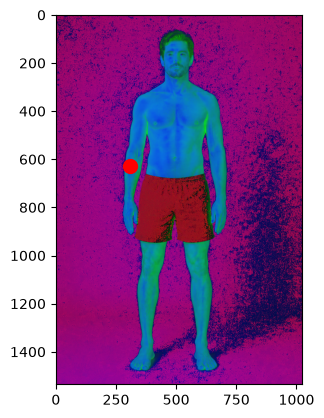

In [4]:
import matplotlib.pyplot as plt
plt.imshow(hsv)
# poi_xy = [410, 610]
plt.scatter(poi_xy[0], poi_xy[1], color='red', s=100)


In [5]:
# anchor on mesh A (pred_vertices already in camera coords; +Z forward; cam_t applied)
mA = trimesh.load('output/poseA/poseA_mesh_000.ply', process=False)


In [6]:
focal = json.load(open('output/poseA/poseA_focal_length.json'))['focal_length']
V, Nn = np.asarray(mA.vertices), np.asarray(mA.vertex_normals)
cx, cy = W/2, H/2

depth = -V[:, 2]                                   # positive; SAM3D is -Z forward
uv = np.stack([ focal*V[:,0]/depth + cx,
               -focal*V[:,1]/depth + cy], 1)        # matches the overlay now

front = Nn[:, 2] > 0                               # -Z forward → toward-camera normal is +Z (was backwards)

d2   = ((uv - poi_xy)**2).sum(1)
near = np.where(d2 < 6**2)[0]
vstar = int(near[np.argmax(V[near, 2])])          # frontmost = least-negative Z

In [7]:
import numpy as np, trimesh

def n_ring(mesh, seed, rings=2):                 # grow P* over topology
    nb, s = mesh.vertex_neighbors, {seed}
    for _ in range(rings):
        s |= {j for i in list(s) for j in nb[i]}
    return np.array(sorted(s))

def color_patch(ply, P, vstar):
    m  = trimesh.load(ply, process=False)
    vc = np.tile([180,180,185,255], (len(m.vertices),1)).astype(np.uint8)  # neutral body
    vc[P]     = [230, 90, 60, 255]               # patch = terracotta
    vc[vstar] = [255, 225, 40, 255]              # anchor vertex = yellow
    m.visual.vertex_colors = vc
    return m

P  = n_ring(trimesh.load('output/poseA/poseA_mesh_000.ply', process=False), vstar, rings=1)
mA = color_patch('output/poseA/poseA_mesh_000.ply', P, vstar)

# print(V[:,2].min(), V[:,2].max())
# mB = color_patch('poseB.ply', P, vstar)          # identical P — that's the whole point

mA.show()                                        # interactive (pyglet)
# mA.export('poseA_patch.ply'); mB.export('poseB_patch.ply')   # or open in MeshLab/Blender

In [8]:
m  = trimesh.load('output/poseA/poseA_mesh_000.ply', process=False); V = np.asarray(m.vertices)
V = np.asarray(m.vertices)
depth = -V[:, 2]                          # positive (body is at Z<0)
u =  focal * V[:, 0] / depth + W/2
v = -focal * V[:, 1] / depth + H/2        # the minus flips Y-up to y-down
uv = np.stack([u, v], 1)
img = cv2.imread('poses/poseA_POI.png')
for x,y in uv.astype(int): cv2.circle(img,(x,y),1,(155,155,155),-1)        # whole silhouette
for x,y in uv[P].astype(int): cv2.circle(img,(x,y),3,(60,90,230),-1)       # patch
cv2.imwrite('poseA_overlay.png', img)

True

In [9]:
import numpy as np, trimesh, json, cv2

mB     = trimesh.load('output/poseB/poseB_mesh_000.ply', process=False)
VB, NB = np.asarray(mB.vertices), np.asarray(mB.vertex_normals)
focalB = json.load(open('output/poseB/poseB_focal_length.json'))['focal_length']
imgB   = cv2.imread('poses/poseB.png'); HB, WB = imgB.shape[:2]

vhat = VB / np.linalg.norm(VB, axis=1, keepdims=True)   # camera(origin)->vertex ray

# orientation: front-facing if outward normal points back toward camera
cos_t = -(NB * vhat).sum(1)                              # +1 facing, ~0 grazing, -1 away
front = cos_t > 0.15

# occlusion: ray from camera through each P vertex; blocked if a nearer surface is hit
locs, ray_i, _ = mB.ray.intersects_location(np.zeros((len(P),3)), vhat[P], multiple_hits=True)
d_v = np.linalg.norm(VB[P], axis=1)
occluded = np.array([
    (np.linalg.norm(locs[ray_i==k], axis=1).min() < d_v[k] - 5e-3) if (ray_i==k).any() else False
    for k in range(len(P))
])

visible = front[P] & ~occluded
print(f'visible {visible.sum()}/{len(P)}   mean cosθ {cos_t[P].mean():+.2f}')
print('DECISION:', 'INCLUDE' if visible.mean() > 0.3 else 'EXCLUDE')

# color-coded overlay: green=visible, grey=occluded, blue=back-facing
uvB = project(VB, focalB, WB, HB)
for k, vi in enumerate(P):
    x, y = uvB[vi].astype(int)
    c = (0,200,0) if visible[k] else ((160,160,160) if occluded[k] else (40,40,220))
    cv2.circle(imgB, (x,y), 3, c, -1)
cv2.imwrite('poseB_decision.png', imgB)

visible 0/7   mean cosθ -0.68
DECISION: EXCLUDE


True